## Survival Austin Cats using Numpyro
By Prabhakar Srivastava

Because the dataset is large I will use Numpyro and the AutoLaplaceApproximation instead of NUTS <br>
Based on the PyMC notebook from PyMC website in Examples.  Modified for the homework problem and for numpyro

In [1]:
# Import Libaries
import pandas as pd
import numpy as np
import jax.numpy as jnp
from jax.random import PRNGKey, split
import numpyro
import numpyro.distributions as dist
from numpyro.handlers import seed
import numpyro.optim as optim
from numpyro.diagnostics import print_summary
from numpyro.infer import Predictive, SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoLaplaceApproximation, AutoNormal
import matplotlib.pyplot as plt
import arviz as az

In [2]:
# Plotting style
plt.style.use("statistical-rethinking-2023.mplstyle")

random_seed = sum(map(ord, "Homework B8 Censored Numpyro"))

numpyro.set_platform("cpu")

In [3]:
# Reading in the data
file_path:str = "https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/AustinCats.csv"

cats_df = pd.read_csv(file_path, sep=";")
cats_df.head()

,id,days_to_event,date_out,out_event,date_in,in_event,breed,color,intake_age
0,A730601,1,07/08/2016 09:00:00 AM,Transfer,07/07/2016 12:11:00 PM,Stray,Domestic Shorthair Mix,Blue Tabby,7
1,A679549,25,06/16/2014 01:54:00 PM,Transfer,05/22/2014 03:43:00 PM,Stray,Domestic Shorthair Mix,Black/White,1
2,A683656,4,07/17/2014 04:57:00 PM,Adoption,07/13/2014 01:20:00 PM,Stray,Snowshoe Mix,Lynx Point,2
3,A709749,41,09/22/2015 12:49:00 PM,Transfer,08/12/2015 06:29:00 PM,Stray,Domestic Shorthair Mix,Calico,12
4,A733551,9,09/01/2016 12:00:00 AM,Transfer,08/23/2016 02:35:00 PM,Stray,Domestic Shorthair Mix,Brown Tabby/White,1


Recode to have color as black non-black and add censor indicator

In [4]:
# Rename color
cats_df.rename(columns={"color": "color_old"}, inplace=True)
cats_df["color"] = np.where(
    cats_df["color_old"] == "Black",
    "black",
    "other"
)

# Add censor indicator
cats_df["censored_ind"] = np.where(
    cats_df["out_event"] == "Adoption",
    0, 
    1
)
cats_df.head()

,id,days_to_event,date_out,out_event,date_in,in_event,breed,color_old,intake_age,color,censored_ind
0,A730601,1,07/08/2016 09:00:00 AM,Transfer,07/07/2016 12:11:00 PM,Stray,Domestic Shorthair Mix,Blue Tabby,7,other,1
1,A679549,25,06/16/2014 01:54:00 PM,Transfer,05/22/2014 03:43:00 PM,Stray,Domestic Shorthair Mix,Black/White,1,other,1
2,A683656,4,07/17/2014 04:57:00 PM,Adoption,07/13/2014 01:20:00 PM,Stray,Snowshoe Mix,Lynx Point,2,other,0
3,A709749,41,09/22/2015 12:49:00 PM,Transfer,08/12/2015 06:29:00 PM,Stray,Domestic Shorthair Mix,Calico,12,other,1
4,A733551,9,09/01/2016 12:00:00 AM,Transfer,08/23/2016 02:35:00 PM,Stray,Domestic Shorthair Mix,Brown Tabby/White,1,other,1


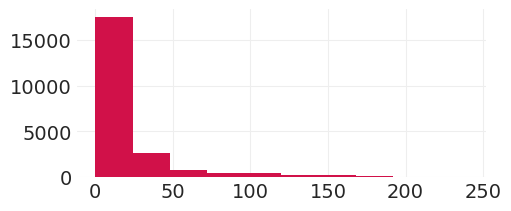

In [5]:
plt.figure(figsize=(5,2))
cats_df["intake_age"].hist(bins=10)
plt.show()

In [6]:
np.quantile(cats_df["intake_age"], [0.75, 0.9, 0.95])

array([12., 48., 84.])

Histogram

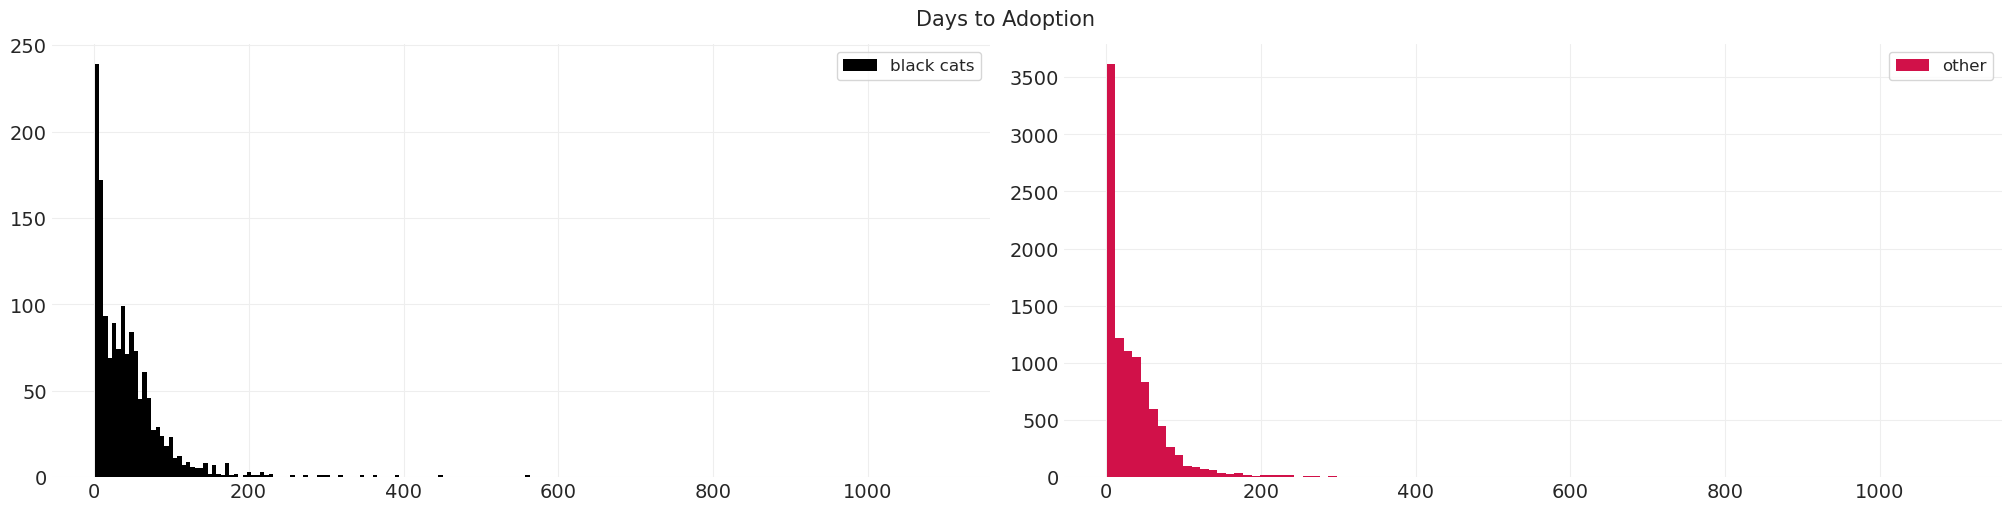

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5), sharex=True)
cats_df[(cats_df["color"]=="black") & (cats_df["out_event"]=="Adoption")]["days_to_event"].hist(bins=100, ax=ax[0], color="k", label="black cats")
ax[0].legend()
cats_df[(cats_df["color"]=="other") & (cats_df["out_event"]=="Adoption")]["days_to_event"].hist(bins=100, ax=ax[1], label="other")
ax[1].legend()
plt.suptitle("Days to Adoption", fontsize=15)
plt.show()

In [8]:
# Mean value of adoptions
cats_df[cats_df["out_event"]=="Adoption"]["days_to_event"].mean()

np.float64(38.401110034358204)

Simulate Exponential Random Variables

In [9]:
# Simulate 4000 random variables
λ = 1/40
z = dist.Exponential(λ).sample(PRNGKey(1234), (4_000,))

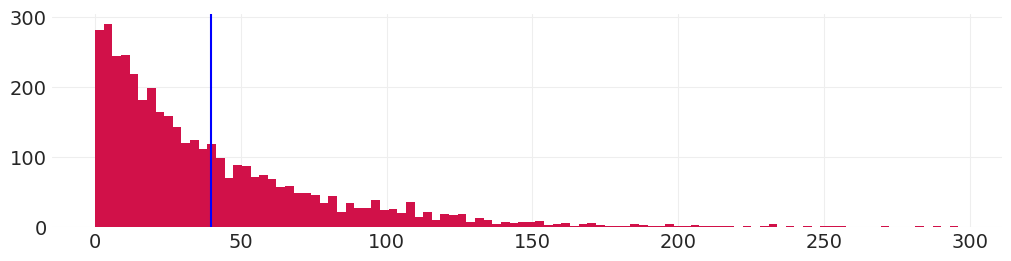

In [10]:
plt.figure(figsize=(10, 2.5))
plt.hist(z, bins=100)
plt.axvline(z.mean(), color="blue")
plt.show()

In [11]:
jnp.log(1/40)

Array(-3.6888795, dtype=float32, weak_type=True)

Also for uncensored observations the likelihood  is $\text{Exponential}(\lambda)$ <br>
But for censored we need 1 - cdf = ccdf

In [12]:
NCOLOR = len(cats_df["color"].unique())

color_id, colors = pd.factorize(cats_df["color"].values, sort=True)

def hm_b08(color_id:jnp.array = jnp.array(color_id),
           days_to_event:jnp.array = jnp.array(cats_df["days_to_event"].values),
           is_censored:jnp.array = jnp.array(cats_df["censored_ind"].values)
          ) -> None:
    '''
    Function to do Censored regression
    '''

    # Priors
    with numpyro.plate("color", NCOLOR):
        α = numpyro.sample("α", dist.Normal(0, 2))
        λ = numpyro.deterministic("λ", jnp.exp(α)) # exp(-4) ~ 1/40 close to the mean

    # pdf of exponential distribution is: lambda * exp(-lambda * t)
    # cdf of exponential distribution is: 1 - exp(-lambda * t)
    # Taking into account censored
    # If cat is adopted: not-censored -> use pdf
    # If cat is not adopted: censored -> use 1 - cdf = ccdf

    log_likelihood = jnp.where(
        is_censored == 0,
        jnp.log(λ[color_id]) - λ[color_id] * days_to_event, #pdf on log scale
        -λ[color_id] * days_to_event # ccdf of log scale
    )

    numpyro.factor("log_likelihood", jnp.sum(log_likelihood))
    

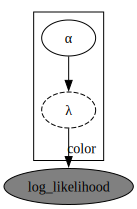

In [13]:
numpyro.render_model(hm_b08)

In [14]:
rng_key = PRNGKey(random_seed)
rng_key, rng_subkey = split(rng_key)
m_hm_b08 = AutoLaplaceApproximation(hm_b08)
svi = SVI(hm_b08, m_hm_b08, optim.Adam(0.01), Trace_ELBO())
svi_result = svi.run(rng_subkey, 4_000)
p_hm_b08 = svi_result.params

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [00:01<00:00, 2311.60it/s, init loss: 1901448.1250, avg. loss [3801-4000]: 55711.6094]


In [15]:
# Posterior
rng_key, rng_subkey = split(rng_key)
post_b08 = m_hm_b08.sample_posterior(rng_subkey, p_hm_b08, sample_shape=(2_000,))

In [16]:
# Convert to arviz
idata_b08 = az.from_dict(
    {"α": post_b08["α"][None, ...],
     "λ": post_b08["λ"][None, ...]
    },
    coords = {"color": colors},
    dims = {"α":["color"], "λ":["color"]}
)

In [17]:
az.summary(idata_b08, round_to=3)[["mean", "sd", "hdi_3%", "hdi_97%"]]

arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%
α[black],-4.052,0.026,-4.101,-4.003
α[other],-3.791,0.009,-3.808,-3.772
λ[black],0.017,0.000,0.017,0.018
λ[other],0.023,0.000,0.022,0.023


Look at mean waiting times: $1/\lambda$

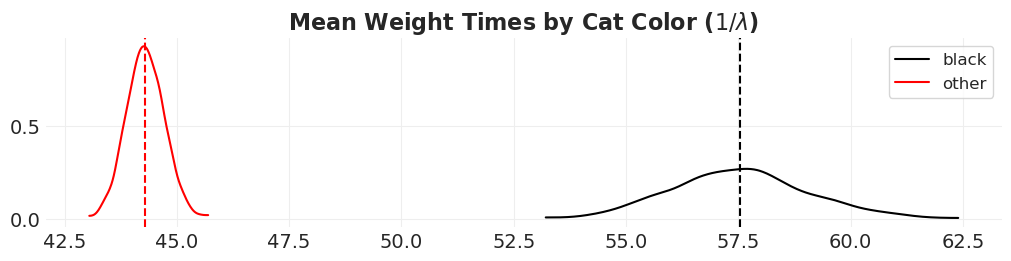

In [18]:
fig, ax = plt.subplots(figsize=(10., 2.5))

for color in ("black", "other"):

    color_to_plot = "k" if color == "black" else "r"
    
    λ = idata_b08.posterior["λ"].sel({"color": color})

    az.plot_dist(1/λ, color=color_to_plot, ax=ax, label=color)

    ax.axvline((1/λ).mean(), color=color_to_plot, ls="--")

ax.set_title(r"Mean Weight Times by Cat Color ($1/\lambda$)", fontweight="bold")
plt.show()

Plot the Survival

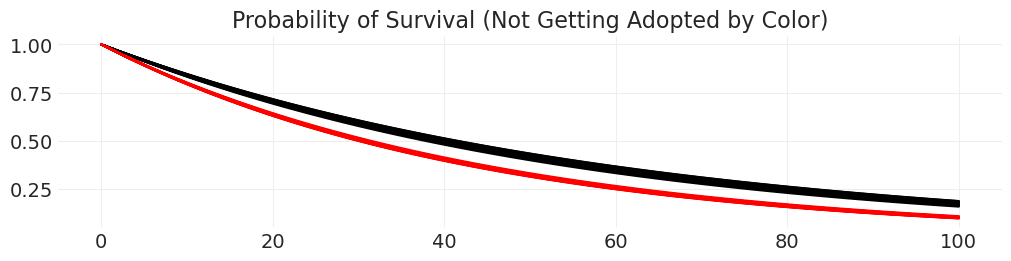

In [19]:
_, ax = plt.subplots(figsize=(10., 2.5))
days_to_adoption = np.linspace(0, 100, 100)

for color in ("black", "other"):

    col = "black" if color=="black" else "r"

    λ_samples = idata_b08.posterior["λ"].sel({"color": color, "chain": 0})[slice(0, 2_000, 50)].to_numpy()

    for λ in λ_samples:
        
        ax.plot(days_to_adoption, np.exp(-λ * days_to_adoption), color=col)

ax.set_title("Probability of Survival (Not Getting Adopted by Color)")
plt.show()

Add Age now: we will bin into less than or equal to 12 week, between 12 and 48 weeks, between 48 and 84 weeks, greater than 84 weeks 

In [20]:
cond_list = [cats_df["intake_age"]<=12, cats_df["intake_age"]<=48, cats_df["intake_age"]<=84]
choice_list = ["<= 12 weeks", ">12 weeks and <= 48 weeks", ">48 weeks and <= 84 weeks"]
cats_df["age"] = np.select(cond_list, choice_list, default=">84 weeks")

In [21]:
age_id, ages = pd.factorize(cats_df["age"], sort=True)
NAGE = len(ages)

In [22]:
def hm_b08_age(color_id:jnp.array = jnp.array(color_id),
               age_id:jnp.array = jnp.array(age_id),
               days_to_event:jnp.array = jnp.array(cats_df["days_to_event"].values),
               is_censored:jnp.array = jnp.array(cats_df["censored_ind"].values)
              ) -> None:
    '''
    Bringing in the Age Variable.  Here age will be discretized into categorical variables.
    Note age will be treated as an ordered predictor!
    '''

    # Prior for ordered effect of age: Use a Dirichelet Prior
    ζ = numpyro.sample("ζ", dist.Dirichlet(jnp.ones(NAGE - 1)))
    η = numpyro.deterministic("η", jnp.concatenate([jnp.array([0.]), jnp.cumsum(ζ)])) # The cumulative ordered effect

    # Prior on coefficient keep it as normal. Let us keep it simple and say it does not vary by color
    β = numpyro.sample("β", dist.Normal(loc=0., scale=1.5))

    # Effect of color
    with numpyro.plate("color", NCOLOR):
        α = numpyro.sample("α", dist.Normal(loc=0., scale=2.5))

    
    # Lambda
    λ = numpyro.deterministic("λ", jnp.exp(α[color_id] + β * η[age_id]))

    # Likelihood on a log scale: recall this is for censored observations
    # Censored == 0: Cat is adopted: use pdf
    # Censored == 1: Cat is not adopted: use 1 - cdf = ccdf
    # pdf = lambda * exp(-lambda * t); logpdf = log(lambda) - lambda * t
    # cdf = 1 - exp(-lambda * t); 1 - cdf = ccdf = exp(-lambda * t); log(ccdf) = -lambda * t

    log_likelihood = jnp.where(
        is_censored == 0,
        jnp.log(λ) - λ * days_to_event,
        - λ * days_to_event
    )

    numpyro.factor("log_likelihood", jnp.sum(log_likelihood))
    

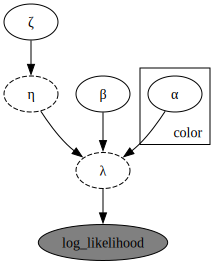

In [23]:
numpyro.render_model(hm_b08_age)

Run the model

In [24]:
rng_key, rng_subkey = split(rng_key) # Split the key
m_hm_b08_age = AutoNormal(hm_b08_age)
svi = SVI(hm_b08_age, m_hm_b08_age, optim.Adam(0.01), Trace_ELBO())
svi_result = svi.run(rng_subkey, 4_000)
p_hm_b08_age = svi_result.params

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [00:02<00:00, 1491.09it/s, init loss: 900807.3125, avg. loss [3801-4000]: 55402.5586]


In [25]:
# Extract the posterior samples
post_b08_age = m_hm_b08_age.sample_posterior(rng_key, p_hm_b08_age, sample_shape = (2_000,))

In [26]:
idata_b08_age = az.from_dict(
    {"α": post_b08_age["α"][None, :],
    "λ": post_b08_age["λ"][None, :],
    "β": post_b08_age["β"][None, :],
    "ζ": post_b08_age["ζ"][None, :],
    "η": post_b08_age["η"][None, :]
    },
    coords = {"color": colors, 
              "age_effect": ["young to medium 1", 
                             "medium 1 to medium 2", 
                             "medium 2 to old"],
              "age": ages,
              "obs": np.arange(len(cats_df))
             },
    dims = {"α": ["color"],
            "ζ": ["age_effect"],
            "η": ["age"],
            "λ": ["obs_id"]
           }    
)

In [27]:
az.summary(idata_b08_age, var_names=["α", "ζ", "η", "β"], round_to=2)[["mean", "sd", "hdi_3%", "hdi_97%"]]

arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)
/Users/prabh/miniconda3/envs/bap3/lib/python3.11/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%
α[black],-3.96,0.03,-4.02,-3.90
α[other],-3.73,0.06,-3.85,-3.62
ζ[young to medium 1],0.61,0.03,0.55,0.67
ζ[medium 1 to medium 2],0.24,0.06,0.13,0.35
ζ[medium 2 to old],0.15,0.06,0.05,0.25
η[<= 12 weeks],0.00,0.00,0.00,0.00
η[>12 weeks and <= 48 weeks],0.61,0.03,0.55,0.67
η[>48 weeks and <= 84 weeks],0.85,0.06,0.75,0.95
η[>84 weeks],1.00,0.00,1.00,1.00
β,-0.85,0.07,-0.97,-0.71


Look at black cats by age

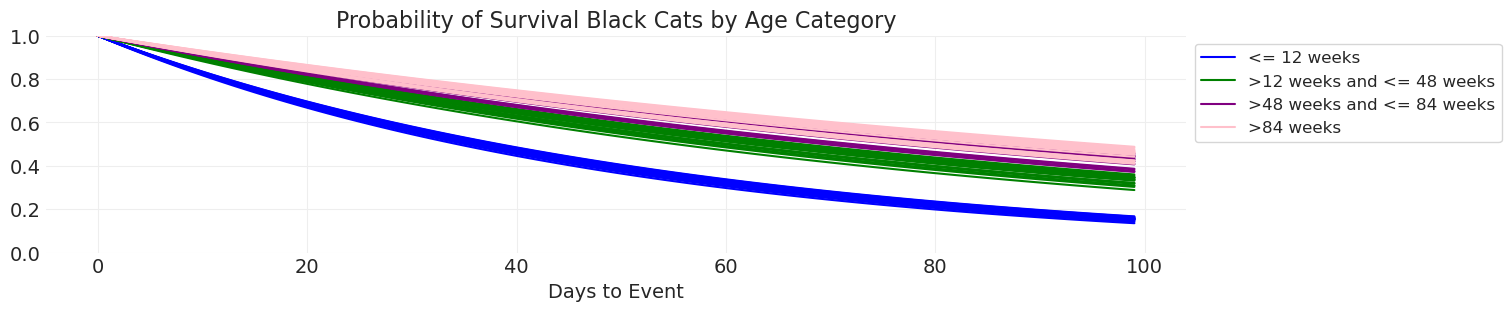

In [28]:
_, ax = plt.subplots(figsize=(15., 3.))
ages_ = ["<= 12 weeks", ">12 weeks and <= 48 weeks", ">48 weeks and <= 84 weeks", ">84 weeks"]
colors = ["blue", "green", "purple", "pink"]

days_to_event = np.arange(0, 100)

for i, a in enumerate(ages_):

    α = idata_b08_age.posterior["α"].sel(color="black").stack(samples=("chain", "draw")).values[None, :]
    β = idata_b08_age.posterior["β"].stack(samples=("chain", "draw")).values[None, :]
    η = idata_b08_age.posterior["η"].sel(age=a).stack(samples=("chain", "draw")).values[None, :]
    λ = jnp.exp(α + β * η)
    
    S = np.exp(-λ * days_to_event[:, None])

    ax.plot(days_to_event, S[:, 0], color=colors[i], label=a)
    ax.plot(days_to_event, S[:, slice(100, 2_000, 100)], color=colors[i])


ax.legend(bbox_to_anchor=(1., 1.))
ax.set_ylim([0, 1])
ax.set(xlabel="Days to Event", title="Probability of Survival Black Cats by Age Category")
plt.show()

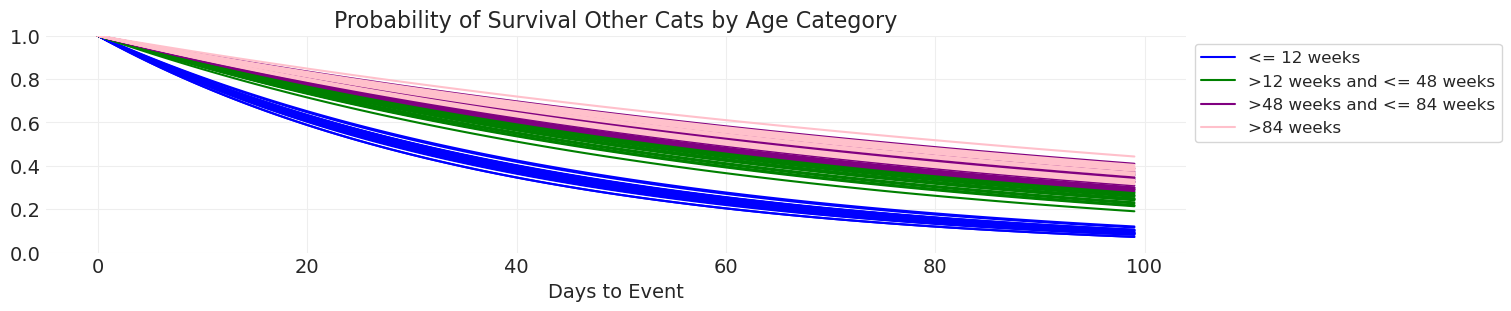

In [29]:
_, ax = plt.subplots(figsize=(15., 3.))
for i, a in enumerate(ages_):

    α = idata_b08_age.posterior["α"].sel(color="other").stack(samples=("chain", "draw")).values[None, :]
    β = idata_b08_age.posterior["β"].stack(samples=("chain", "draw")).values[None, :]
    η = idata_b08_age.posterior["η"].sel(age=a).stack(samples=("chain", "draw")).values[None, :]
    λ = jnp.exp(α + β * η)
    
    S = np.exp(-λ * days_to_event[:, None])

    ax.plot(days_to_event, S[:, 0], color=colors[i], label=a)
    ax.plot(days_to_event, S[:, slice(100, 2_000, 100)], color=colors[i])


ax.legend(bbox_to_anchor=(1., 1.))
ax.set_ylim([0, 1])
ax.set(xlabel="Days to Event", title="Probability of Survival Other Cats by Age Category")
plt.show()

Younger cats are adopted faster

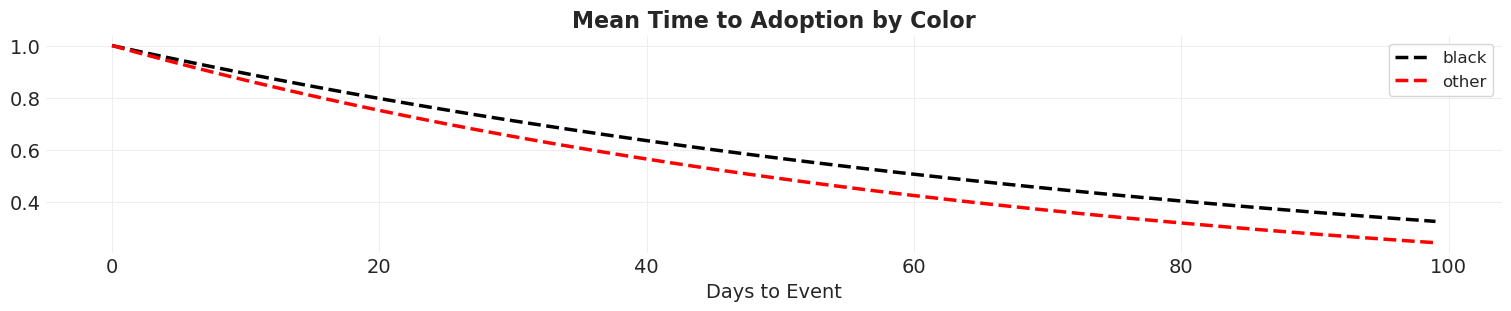

In [30]:
fig, ax = plt.subplots(figsize=(15., 3.))

# Mean for black cates
α = idata_b08_age.posterior["α"].sel(color="black").stack(samples=("chain", "draw")).values[None, :]
β = idata_b08_age.posterior["β"].stack(samples=("chain", "draw")).values[None, :]
η = idata_b08_age.posterior["η"].mean(dim="age").stack(samples=("chain", "draw")).values[None, :]
λ = jnp.exp(α + β * η)
    
S = np.exp(-λ * days_to_event[:, None])
ax.plot(days_to_event, S.mean(axis=1), color="k", label="black", lw=2.5, ls="--")

# Mean for other cats
α = idata_b08_age.posterior["α"].sel(color="other").stack(samples=("chain", "draw")).values[None, :]
λ = jnp.exp(α + β * η)
    
S = np.exp(-λ * days_to_event[:, None])
ax.plot(days_to_event, S.mean(axis=1), color="red", label="other", lw=2.5, ls="--")

ax.legend()
ax.set_xlabel("Days to Event")
ax.set_title("Mean Time to Adoption by Color", fontweight="bold")
plt.show()